# Plot Ta, VPD projection and extreme VPD days

In [104]:
from datetime import timedelta
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Read files for CNRM-CERFACS_CNRM-CM6-1-HR, MOHC_HadGEM3-GC31-MM, and NOAA-GFDL_GFDL-ESM4

In [107]:
def read_year_mean_his(model):    
    his_path = '.\\data\\VPD\\' + model + '\\historical\\historical_' + model + '_VPD_filtered.csv'
    all_his = pd.read_csv(his_path, parse_dates=['time'])
    all_his = all_his[(all_his['time'] >= '1980-01-01') & (all_his['time'] < '2015-01-01')]
    
    # Check if the first row's time is 1980-01-01
    if all_his['time'].iloc[0].date() != pd.Timestamp('1980-01-01').date():
        # If not, remove all rows for the year 1980
        all_his = all_his[all_his['time'].dt.year != 1980]
        
    # Check if the last row's time is 2014-12-31
    if all_his['time'].iloc[-1].date() != pd.Timestamp('2014-12-31').date():
        # If not, remove all rows for the year 2014
        all_his = all_his[all_his['time'].dt.year != 2014]
    # print(all_his)
    
    #hourly to daily max to yearly mean
    all_his_daily_max = all_his.resample('D',on='time').max()
    all_his_yearly_mean = all_his_daily_max.resample('YE').mean()

    all_his_yearly_mean.index = all_his_yearly_mean.index.year

    return all_his_yearly_mean, all_his_daily_max

def read_year_mean_ssp(model, ssp):    
    ssp_path = '.\\data\\VPD\\' + model + '\\' + ssp + '\\' + ssp + '_' + model + '_VPD_filtered.csv'
    all_ssp = pd.read_csv(ssp_path, parse_dates=['time'])
    # print(all_ssp)
    all_ssp = all_ssp[(all_ssp['time'] >= '2015-01-01') & (all_ssp['time'] < '2101-01-01')]
    
    # Check if the first row's time is 2015-01-01
    if all_ssp['time'].iloc[0].date() != pd.Timestamp('2015-01-01').date():
        # If not, remove all rows for the year 2015
        all_ssp = all_ssp[all_ssp['time'].dt.year != 2015]
        
    # Check if the last row's time is 2100-12-31
    if all_ssp['time'].iloc[-1].date() != pd.Timestamp('2100-12-31').date():
        # If not, remove all rows for the year 2100
        all_ssp = all_ssp[all_ssp['time'].dt.year != 2100]
    
    # print(all_ssp)
    #hourly to daily max to yearly mean
    all_ssp_daily_max = all_ssp.resample('D',on='time').max()
    all_ssp_yearly_mean = all_ssp_daily_max.resample('YE').mean()

    all_ssp_yearly_mean.index = all_ssp_yearly_mean.index.year

    return all_ssp_yearly_mean, all_ssp_daily_max

model = 'CNRM-CERFACS_CNRM-CM6-1-HR'
CNRM_yearly_his, CNRM_daily_his = read_year_mean_his(model)
CNRM_yearly_ssp126, CNRM_daily_ssp126 = read_year_mean_ssp(model, 'ssp126')
CNRM_yearly_ssp585, CNRM_daily_ssp585 = read_year_mean_ssp(model, 'ssp585')
# print(CNRM_yearly_ssp126)
# print(CNRM_yearly_ssp585)

model = 'MOHC_HadGEM3-GC31-MM'
MOHC_yearly_his, MOHC_daily_his = read_year_mean_his(model)
MOHC_yearly_ssp126, MOHC_daily_ssp126 = read_year_mean_ssp(model, 'ssp126')
MOHC_yearly_ssp585, MOHC_daily_ssp585 = read_year_mean_ssp(model, 'ssp585')
# print(MOHC_yearly_ssp126)

model = 'NOAA-GFDL_GFDL-ESM4'
NOAA_yearly_his, NOAA_daily_his = read_year_mean_his(model)
NOAA_yearly_ssp126, NOAA_daily_ssp126 = read_year_mean_ssp(model, 'ssp126')
NOAA_yearly_ssp245, NOAA_daily_ssp245 = read_year_mean_ssp(model, 'ssp245')
NOAA_yearly_ssp370, NOAA_daily_ssp370 = read_year_mean_ssp(model, 'ssp370')
NOAA_yearly_ssp585, NOAA_daily_ssp585 = read_year_mean_ssp(model, 'ssp585')

Read files for CESM

In [110]:
def read_year_mean_his_CESM(model):    
    his_path = '.\\data\\VPD\\' + model + '\\historical\\historical_' + model + '_VPD.csv'
    all_his = pd.read_csv(his_path, parse_dates=['date'])
   
    all_his['date'] = (all_his['date'] - timedelta(hours=4)) #convert UTC to local time
    all_his = all_his[(all_his['date'] >= '1980-01-01') & (all_his['date'] < '2015-01-01')]
    
    # Check if the first row's time is 1980-01-01
    if all_his['date'].iloc[0].date() != pd.Timestamp('1980-01-01').date():
        # If not, remove all rows for the year 1980
        all_his = all_his[all_his['date'].dt.year != 1980]
        
    # Check if the last row's time is 2014-12-31
    if all_his['date'].iloc[-1].date() != pd.Timestamp('2014-12-31').date():
        # If not, remove all rows for the year 2014
        all_his = all_his[all_his['date'].dt.year != 2014]
        
    # print(all_his)
    #hourly to daily max to yearly mean
    all_his_daily_max = all_his.resample('D',on='date').max()
    all_his_yearly_mean = all_his_daily_max.resample('YE').mean()
    
    all_his_yearly_mean.index = all_his_yearly_mean.index.year
    # print(all_his_yearly_mean)
    return all_his_yearly_mean, all_his_daily_max

def read_year_mean_ssp_CESM(model):    
    ssp_path = '.\\data\\VPD\\' + model + '\\SSP\\' + model + '_ssp_combined.csv'
    all_ssp = pd.read_csv(ssp_path, parse_dates=['date'])
    
    all_ssp['date'] = all_ssp['date'] -timedelta(hours=4) #convert UTC to local time
    all_ssp = all_ssp[(all_ssp['date'] >= '2015-01-01') & (all_ssp['date'] < '2101-01-01')]
    
    # Check if the first row's time is 2100-12-31
    if all_ssp['date'].iloc[0].date() != pd.Timestamp('2015-01-01').date():
        # If not, remove all rows for the year 2015
        all_ssp = all_ssp[all_ssp['date'].dt.year != 2015]  
        
    # Check if the last row's time is 2100-12-31
    if all_ssp['date'].iloc[-1].date() != pd.Timestamp('2100-12-31').date():
        # If not, remove all rows for the year 2100
        all_ssp = all_ssp[all_ssp['date'].dt.year != 2100]    
    # print(all_ssp)
    
    #hourly to daily max to yearly mean
    all_ssp_daily_max = all_ssp.resample('D',on='date').max()
    all_ssp_yearly_mean = all_ssp_daily_max.resample('YE').mean()
    
    all_ssp_yearly_mean.index = all_ssp_yearly_mean.index.year
    return all_ssp_yearly_mean, all_ssp_daily_max

model = 'CESM'
CESM_yearly_his, CESM_daily_his = read_year_mean_his_CESM(model)
CESM_yearly_ssp, CESM_daily_ssp = read_year_mean_ssp_CESM(model)
# print(CESM_yearly_his)
# print(CESM_yearly_ssp)

Read file for E3SM

In [113]:
def read_year_mean_E3SM(model):    
    file_path = '.\\data\\VPD\\' + model + '\\' + model + '_VPD.csv'
    all_data = pd.read_csv(file_path, parse_dates=['time_bnds'])
    # print(all_data)
    
    all_data['time_bnds'] = all_data['time_bnds'] -timedelta(hours=4) #convert UTC to local time

    all_data = all_data[(all_data['time_bnds'] >= '1980-01-01') & (all_data['time_bnds'] < '2101-01-01')]
    
    # Check if the first row's time is 1980-01-01
    if all_data['time_bnds'].iloc[0].date() != pd.Timestamp('1980-01-01').date():
        # If not, remove all rows for the year 1980
        all_data = all_data[all_data['time_bnds'].dt.year != 1980]  
        
    # Check if the last row's time is 2100-12-31
    if all_data['time_bnds'].iloc[-1].date() != pd.Timestamp('2100-12-31').date():
        # If not, remove all rows for the year 2100
        all_data = all_data[all_data['time_bnds'].dt.year != 2100]    
 
    
    # print(all_data)
    

    #hourly to daily max to yearly mean
    all_daily_max = all_data.resample('D',on='time_bnds').max().apply(pd.to_numeric, errors='coerce')
    # print(all_daily_max.dtypes)
    # print(all_daily_max)
    all_yearly_mean = all_daily_max.resample('YE').mean()
    # print(all_yearly_mean)
    all_yearly_mean.index = all_yearly_mean.index.year

    return all_yearly_mean, all_daily_max

model = 'E3SM_BCRD'
E3SM_BCRD_yearly, E3SM_BCRD_daily = read_year_mean_E3SM(model)
# print(f'E3SM_BCRD_yearly {E3SM_BCRD_yearly}')

model = 'E3SM_BDRD'
E3SM_BDRD_yearly, E3SM_BDRD_daily = read_year_mean_E3SM(model)
# print(f'E3SM_BDRD_yearly {E3SM_BDRD_yearly}')
E3SM_BDRD_yearly.to_csv('test.csv')
E3SM_BDRD_daily.to_csv('test1.csv')

Plot extreme days from 1980 to 2100

Plot extreme days in every month in 2050

In [127]:
## Plot extreme VPD days time series and in every month 2050 in one plot (modified on 08/20/2025)

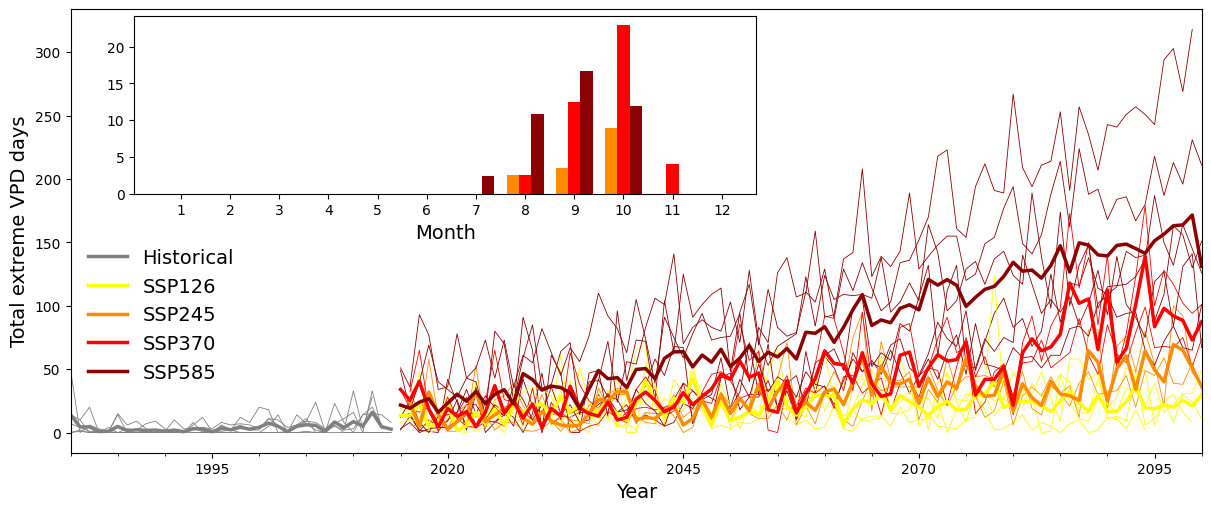

In [128]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ======================
# Thresholds
# ======================
CNRM_threshold = 27.024601353296315
MOHC_threshold = 38.4032999247096
NOAA_threshold = 51.17654503990564
CESM_threshold = 44.21403417992513
E3SM_BCRD_threshold = 36.96984881497566
E3SM_BDRD_threshold = 35.48145103898043


def calculate_extreme_days(df, column, threshold, freq="YE"):
    extreme_vpd_days = df[df[column] > threshold].resample(freq).size()
    return extreme_vpd_days.to_frame(name="extreme_vpd_days")

# ======================
# === First Plot (time series) ===
# ======================
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

# CNRM Historical
CNRM_daily_his_extreme_vpd_days = calculate_extreme_days(CNRM_daily_his, 'VPD', CNRM_threshold)
# CNRM_daily_his_extreme_vpd_days = fill_missing_value_his(CNRM_daily_his_extreme_vpd_days)
CNRM_daily_his_extreme_vpd_days.plot(ax=ax, label='CNRM Historical', color=scenario_colors['Historical'], linewidth=0.6)

# CNRM SSP126
CNRM_daily_ssp126_extreme_vpd_days = calculate_extreme_days(CNRM_daily_ssp126, 'VPD', CNRM_threshold)
CNRM_daily_ssp126_extreme_vpd_days.loc['2045-01-01':'2055-12-31'] = np.nan
CNRM_daily_ssp126_extreme_vpd_days.plot(ax=ax, label='CNRM SSP126', color=scenario_colors['SSP126'], linewidth=0.6)

# CNRM SSP585
CNRM_daily_ssp585_extreme_vpd_days = calculate_extreme_days(CNRM_daily_ssp585, 'VPD', CNRM_threshold)
CNRM_daily_ssp585_extreme_vpd_days.plot(ax=ax, label='CNRM SSP585', color=scenario_colors['SSP585'], linewidth=0.6)

# MOHC Historical
MOHC_daily_his_extreme_vpd_days = calculate_extreme_days(MOHC_daily_his, 'VPD', MOHC_threshold)
# MOHC_daily_his_extreme_vpd_days = fill_missing_value_his(MOHC_daily_his_extreme_vpd_days)
MOHC_daily_his_extreme_vpd_days.plot(ax=ax, label='MOHC Historical', color=scenario_colors['Historical'], linewidth=0.6)

# MOHC SSP126
MOHC_daily_ssp126_extreme_vpd_days = calculate_extreme_days(MOHC_daily_ssp126, 'VPD', MOHC_threshold)
MOHC_daily_ssp126_extreme_vpd_days.plot(ax=ax, label='MOHC SSP126', color=scenario_colors['SSP126'], linewidth=0.6)

# MOHC SSP585
MOHC_daily_ssp585_extreme_vpd_days = calculate_extreme_days(MOHC_daily_ssp585, 'VPD', MOHC_threshold)
MOHC_daily_ssp585_extreme_vpd_days.plot(ax=ax, label='MOHC SSP585', color=scenario_colors['SSP585'], linewidth=0.6)

# NOAA Historical
NOAA_daily_his_extreme_vpd_days = calculate_extreme_days(NOAA_daily_his, 'VPD', NOAA_threshold)
# NOAA_daily_his_extreme_vpd_days = fill_missing_value_his(NOAA_daily_his_extreme_vpd_days)
NOAA_daily_his_extreme_vpd_days.plot(ax=ax, label='NOAA Historical', color=scenario_colors['Historical'], linewidth=0.6)

# NOAA SSP126
NOAA_daily_ssp126_extreme_vpd_days = calculate_extreme_days(NOAA_daily_ssp126, 'VPD', NOAA_threshold)
NOAA_daily_ssp126_extreme_vpd_days.plot(ax=ax, label='NOAA SSP126', color=scenario_colors['SSP126'], linewidth=0.6)

# NOAA SSP245
NOAA_daily_ssp245_extreme_vpd_days = calculate_extreme_days(NOAA_daily_ssp245, 'VPD', NOAA_threshold)
NOAA_daily_ssp245_extreme_vpd_days.plot(ax=ax, label='NOAA SSP245', color=scenario_colors['SSP245'], linewidth=0.6)

# NOAA SSP370
NOAA_daily_ssp370_extreme_vpd_days = calculate_extreme_days(NOAA_daily_ssp370, 'VPD', NOAA_threshold)
NOAA_daily_ssp370_extreme_vpd_days.plot(ax=ax, label='NOAA SSP370', color=scenario_colors['SSP370'], linewidth=0.6)

# NOAA SSP585
NOAA_daily_ssp585_extreme_vpd_days = calculate_extreme_days(NOAA_daily_ssp585, 'VPD', NOAA_threshold)
NOAA_daily_ssp585_extreme_vpd_days.plot(ax=ax, label='NOAA SSP585', color=scenario_colors['SSP585'], linewidth=0.6)

# CESM Historical
CESM_daily_his_extreme_vpd_days = calculate_extreme_days(CESM_daily_his, 'CESM_hist_vpd', CESM_threshold)
# CESM_daily_his_extreme_vpd_days = fill_missing_value_his(CESM_daily_his_extreme_vpd_days)
CESM_daily_his_extreme_vpd_days.plot(ax=ax, label='CESM Historical', color=scenario_colors['Historical'], linewidth=0.6)

# CESM SSP126
CESM_daily_ssp126_extreme_vpd_days = calculate_extreme_days(CESM_daily_ssp, 'SSP126_VPD', CESM_threshold)
CESM_daily_ssp126_extreme_vpd_days.plot(ax=ax, label='CESM SSP126', color=scenario_colors['SSP126'], linewidth=0.6)

# CESM SSP245
CESM_daily_ssp245_extreme_vpd_days = calculate_extreme_days(CESM_daily_ssp, 'SSP245_VPD', CESM_threshold)
CESM_daily_ssp245_extreme_vpd_days.plot(ax=ax, label='CESM SSP245', color=scenario_colors['SSP245'], linewidth=0.6)

# CESM SSP370
CESM_daily_ssp370_extreme_vpd_days = calculate_extreme_days(CESM_daily_ssp, 'SSP370_VPD', CESM_threshold)
CESM_daily_ssp370_extreme_vpd_days.plot(ax=ax, label='CESM SSP370', color=scenario_colors['SSP370'], linewidth=0.6)

# CESM SSP585
CESM_daily_ssp585_extreme_vpd_days = calculate_extreme_days(CESM_daily_ssp, 'SSP585_VPD', CESM_threshold)
CESM_daily_ssp585_extreme_vpd_days.plot(ax=ax, label='CESM SSP585', color=scenario_colors['SSP585'], linewidth=0.6)



# Split E3SM_BCRD and E3SM_BDRD into historical and SSP parts
E3SM_BCRD_daily_his = E3SM_BCRD_daily.loc['1980-01-01':'2014-12-31'].drop(columns=['date'])
E3SM_BCRD_daily_ssp585 = E3SM_BCRD_daily.loc['2015-01-01':'2101-01-01'].drop(columns=['date'])
E3SM_BDRD_daily_his = E3SM_BDRD_daily.loc['1980-01-01':'2014-12-31'].drop(columns=['date'])
E3SM_BDRD_daily_ssp585 = E3SM_BDRD_daily.loc['2015-01-01':'2101-01-01'].drop(columns=['date'])
# print(E3SM_BDRD_daily_his)
# BCRD_daily_his_extreme_vpd_days = fill_missing_value_his(BCRD_daily_his_extreme_vpd_days)
# BDRD_daily_his_extreme_vpd_days = fill_missing_value_his(BDRD_daily_his_extreme_vpd_days)

# BCRD Historical
BCRD_daily_his_extreme_vpd_days = calculate_extreme_days(E3SM_BCRD_daily_his, 'vpd', E3SM_BCRD_threshold)
date_range = pd.date_range(start='1980-12-31', end='2014-12-31', freq='YE')
BCRD_daily_his_extreme_vpd_days = BCRD_daily_his_extreme_vpd_days.reindex(date_range, fill_value=0)
# print(BCRD_daily_his_extreme_vpd_days)
BCRD_daily_his_extreme_vpd_days.plot(ax=ax, label='BCRD Historical', color=scenario_colors['Historical'], linewidth=0.6)
# print(BCRD_daily_his_extreme_vpd_days)


# BCRD SSP585
BCRD_daily_ssp585_extreme_vpd_days = calculate_extreme_days(E3SM_BCRD_daily_ssp585, 'vpd', E3SM_BCRD_threshold)
BCRD_daily_ssp585_extreme_vpd_days.plot(ax=ax, label='BCRD SSP585', color=scenario_colors['SSP585'], linewidth=0.6)

# BDRD Historical
BDRD_daily_his_extreme_vpd_days = calculate_extreme_days(E3SM_BDRD_daily_his, 'vpd', E3SM_BDRD_threshold)
date_range = pd.date_range(start='1980-12-31', end='2014-12-31', freq='YE')
BDRD_daily_his_extreme_vpd_days = BDRD_daily_his_extreme_vpd_days.reindex(date_range, fill_value=0)
BDRD_daily_his_extreme_vpd_days.plot(ax=ax, label='BDRD Historical', color=scenario_colors['Historical'], linewidth=0.6)
# print(BCRD_daily_his_extreme_vpd_days)
# print(BDRD_daily_his_extreme_vpd_days)

# BCRD SSP585
BDRD_daily_ssp585_extreme_vpd_days = calculate_extreme_days(E3SM_BDRD_daily_ssp585, 'vpd', E3SM_BDRD_threshold)
BDRD_daily_ssp585_extreme_vpd_days.plot(ax=ax, label='BDRD SSP585', color=scenario_colors['SSP585'], linewidth=0.6)
# print(type(BDRD_daily_ssp585_extreme_vpd_days))
# print(BDRD_daily_ssp585_extreme_vpd_days)
# print(type(BDRD_daily_ssp585_extreme_vpd_days.index))


# Calculate and plot all-model means with thick lines (yearly)
# mean_historical_extreme_vpd = (
#     CNRM_daily_his_extreme_vpd_days + 
#     MOHC_daily_his_extreme_vpd_days + 
#     NOAA_daily_his_extreme_vpd_days + 
#     CESM_daily_his_extreme_vpd_days +
#     BCRD_daily_his_extreme_vpd_days + 
#     BDRD_daily_his_extreme_vpd_days
# ) / 6 

mean_historical_extreme_vpd = pd.concat([
    CNRM_daily_his_extreme_vpd_days,
    MOHC_daily_his_extreme_vpd_days,
    NOAA_daily_his_extreme_vpd_days,
    CESM_daily_his_extreme_vpd_days,
    BCRD_daily_his_extreme_vpd_days,
    BDRD_daily_his_extreme_vpd_days
], axis=1)
mean_historical_extreme_vpd = mean_historical_extreme_vpd.mean(axis=1, skipna=True)
# print(mean_historical_extreme_vpd)
mean_historical_extreme_vpd.plot(ax=ax, label='All model historical mean',
        color=scenario_colors['Historical'], linewidth=2.5)

# Calculate and plot all-model means with thick lines (yearly)
# mean_ssp126_extreme_vpd = (
#     CNRM_daily_ssp126_extreme_vpd_days + 
#     MOHC_daily_ssp126_extreme_vpd_days + 
#     NOAA_daily_ssp126_extreme_vpd_days + 
#     CESM_daily_ssp126_extreme_vpd_days
# ) / 4

mean_ssp126_extreme_vpd = pd.concat([
    CNRM_daily_ssp126_extreme_vpd_days,
    MOHC_daily_ssp126_extreme_vpd_days,
    NOAA_daily_ssp126_extreme_vpd_days,
    CESM_daily_ssp126_extreme_vpd_days
], axis=1)
mean_ssp126_extreme_vpd = mean_ssp126_extreme_vpd.mean(axis=1, skipna=True)

mean_ssp126_extreme_vpd.plot(ax=ax, label='All model SSP126 mean',
        color=scenario_colors['SSP126'], linewidth=2.5)
# print(CNRM_daily_ssp126_extreme_vpd_days)

# Calculate and plot all-model means with thick lines (yearly)
# mean_ssp245_extreme_vpd = (
#     NOAA_daily_ssp245_extreme_vpd_days + 
#     CESM_daily_ssp245_extreme_vpd_days
# ) / 2
mean_ssp245_extreme_vpd = pd.concat([
    NOAA_daily_ssp245_extreme_vpd_days,
    CESM_daily_ssp245_extreme_vpd_days
], axis=1)
mean_ssp245_extreme_vpd = mean_ssp245_extreme_vpd.mean(axis=1, skipna=True)
mean_ssp245_extreme_vpd.plot(ax=ax, label='All model SSP245 mean',
        color=scenario_colors['SSP245'], linewidth=2.5)


# Calculate and plot all-model means with thick lines (yearly)
# mean_ssp370_extreme_vpd = (
#     NOAA_daily_ssp370_extreme_vpd_days + 
#     CESM_daily_ssp370_extreme_vpd_days
# ) / 2
mean_ssp370_extreme_vpd = pd.concat([
    NOAA_daily_ssp370_extreme_vpd_days,
    CESM_daily_ssp370_extreme_vpd_days
], axis=1)
mean_ssp370_extreme_vpd = mean_ssp370_extreme_vpd.mean(axis=1, skipna=True)
mean_ssp370_extreme_vpd.plot(ax=ax, label='All model SSP370 mean',
        color=scenario_colors['SSP370'], linewidth=2.5)

# Calculate and plot all-model means with thick lines (yearly)
# mean_ssp585_extreme_vpd = (
#     CNRM_daily_ssp585_extreme_vpd_days + 
#     MOHC_daily_ssp585_extreme_vpd_days + 
#     NOAA_daily_ssp585_extreme_vpd_days + 
#     CESM_daily_ssp585_extreme_vpd_days +
#     BCRD_daily_ssp585_extreme_vpd_days + 
#     BDRD_daily_ssp585_extreme_vpd_days
# ) / 6
mean_ssp585_extreme_vpd = pd.concat([
    CNRM_daily_ssp585_extreme_vpd_days,
    MOHC_daily_ssp585_extreme_vpd_days,
    NOAA_daily_ssp585_extreme_vpd_days,
    CESM_daily_ssp585_extreme_vpd_days,
    BCRD_daily_ssp585_extreme_vpd_days,
    BDRD_daily_ssp585_extreme_vpd_days
], axis=1)
mean_ssp585_extreme_vpd = mean_ssp585_extreme_vpd.mean(axis=1, skipna=True)
mean_ssp585_extreme_vpd.plot(ax=ax, label='All model SSP370 mean',
        color=scenario_colors['SSP585'], linewidth=2.5)

ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Total extreme VPD days", fontsize=14)

# Legend formatting (same as your original)
handles, labels = ax.get_legend_handles_labels()
selected_handles = handles[-5:]
selected_labels = [
    # "Historical", "SSP126", "SSP245", "SSP370", "SSP585",
    "Historical", "SSP126", "SSP245",
    "SSP370", "SSP585"
]
ax.legend(
    selected_handles,
    selected_labels,
    loc="lower left",
    bbox_to_anchor=(0, 0.12),   # (x, y) shift: 0.2 makes it higher
    frameon=False,
    fontsize=14
)



# ======================
# === Second Plot (Inset bar plot for 2050) ===
# ======================
# Calculate monthly means in 2050
def calc_2050_mean(df, column, threshold):
    return calculate_extreme_days(df, column, threshold, "ME").loc['2050-01-01':'2050-12-31']

mean_ssp245_extreme_vpd = (
    calc_2050_mean(NOAA_daily_ssp245, 'VPD', NOAA_threshold) +
    calc_2050_mean(CESM_daily_ssp, 'SSP245_VPD', CESM_threshold)
) / 2

mean_ssp370_extreme_vpd = (
    calc_2050_mean(NOAA_daily_ssp370, 'VPD', NOAA_threshold) +
    calc_2050_mean(CESM_daily_ssp, 'SSP370_VPD', CESM_threshold)
) / 2

mean_ssp585_extreme_vpd = (
    calc_2050_mean(CNRM_daily_ssp585, 'VPD', CNRM_threshold) +
    calc_2050_mean(MOHC_daily_ssp585, 'VPD', MOHC_threshold) +
    calc_2050_mean(NOAA_daily_ssp585, 'VPD', NOAA_threshold) +
    calc_2050_mean(CESM_daily_ssp, 'SSP585_VPD', CESM_threshold) +
    calc_2050_mean(E3SM_BCRD_daily.loc['2050-01-01':'2050-12-31'], 'vpd', E3SM_BCRD_threshold) +
    calc_2050_mean(E3SM_BDRD_daily.loc['2050-01-01':'2050-12-31'], 'vpd', E3SM_BDRD_threshold)
) / 6

# Grouped bar data
scenarios = ["SSP245", "SSP370", "SSP585"]
scenario_colors = {"SSP245": "darkorange", "SSP370": "red", "SSP585": "darkred"}
mean_vpd_data = [
    mean_ssp245_extreme_vpd['extreme_vpd_days'].values,
    mean_ssp370_extreme_vpd['extreme_vpd_days'].values,
    mean_ssp585_extreme_vpd['extreme_vpd_days'].values
]

months = np.arange(1, 13)
x = np.arange(len(months))
bar_width = 0.25

# Create inset
# ax_inset = inset_axes(ax, width="40%", height="40%", loc="upper left")
ax_inset = inset_axes(
    ax,
    width="55%", height="40%",    # make it wider (e.g., 55%)
    loc="upper left",
    bbox_to_anchor=(0.05, 0, 1, 1),  # shift right by increasing x (0.13 = ~13% right)
    bbox_transform=ax.transAxes
)

for i, (scenario, color) in enumerate(zip(scenarios, scenario_colors.values())):
    ax_inset.bar(x + i * bar_width, mean_vpd_data[i], bar_width,
                 label=scenario, color=color)

# Format inset
ax_inset.set_xticks(x + bar_width)
ax_inset.set_xticklabels(months, fontsize=10)
ax_inset.set_xlabel("Month", fontsize=14)
# ax_inset.set_ylabel("Days", fontsize=8)
ax_inset.tick_params(axis="both", labelsize=10)
# ax_inset.legend(fontsize=6, loc="upper right")

# plt.tight_layout()
plt.savefig("pics/extreme_vpd_days_08_20_2025.eps", format="eps", dpi=1500, bbox_inches="tight")
plt.savefig("pics/extreme_vpd_days_08_20_2025.pdf",
            format="pdf", dpi=1500, bbox_inches="tight")

plt.show()


Plot extreme VPD days for every month within 10-year interval from 2020 to 2100

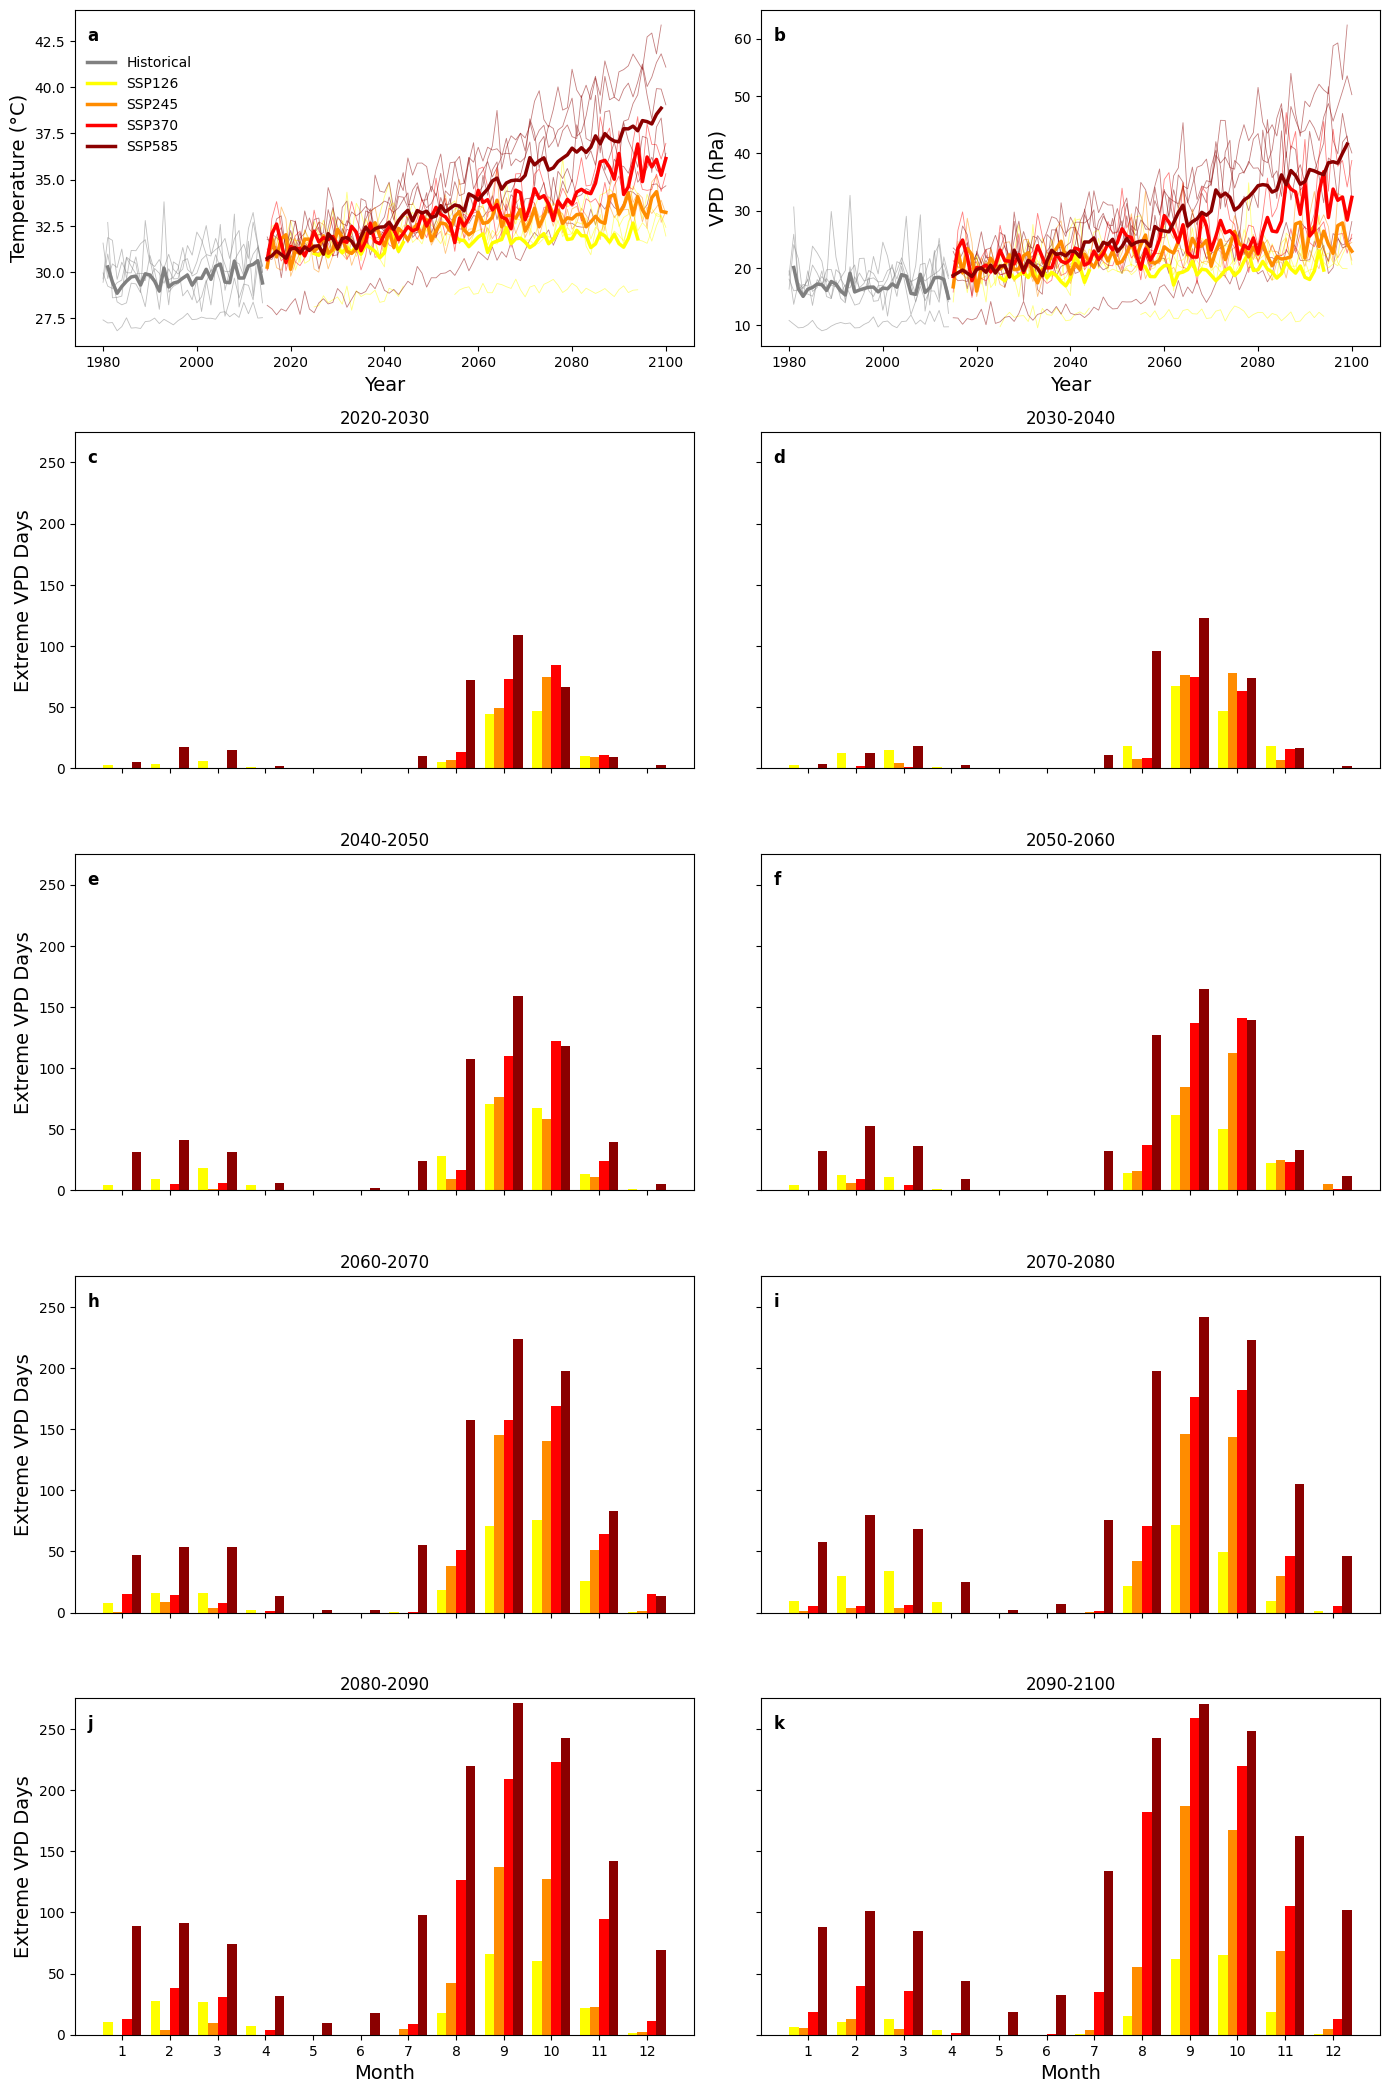

In [24]:
import matplotlib.pyplot as plt

# # Create a figure with 2 subplots (stacked vertically)
# fig, axes = plt.subplots(1, 2, figsize=(24, 6), sharex=True)
# Create 3 rows × 2 columns grid
fig, axes = plt.subplots(
    nrows=5, ncols=2, 
    figsize=(14, 24)
)
# Flatten axes for easier indexing
axes = axes.flatten()

# Define scenario colors
scenario_colors = {
    'Historical': 'gray',
    'SSP126': 'yellow',
    'SSP245': 'darkorange',
    'SSP370': 'red',
    'SSP585': 'darkred'
}

# ===============================
# 🔹 First subplot (TA)
# ===============================
ax = axes[0]

# Define scenario colors
scenario_colors = {
    'Historical': 'gray',
    'SSP126': 'yellow',
    'SSP245': 'darkorange',
    'SSP370': 'red',
    'SSP585': 'darkred'
}

# Plot each model's data with thin lines (no labels for legend)
CNRM_yearly_his.plot(y='Ta', ax=ax, color=scenario_colors['Historical'], alpha=0.5, linewidth=0.6, legend=False)
CNRM_yearly_ssp126.plot(y='Ta', ax=ax, color=scenario_colors['SSP126'], alpha=0.5, linewidth=0.6, legend=False)
CNRM_yearly_ssp585.plot(y='Ta', ax=ax, color=scenario_colors['SSP585'], alpha=0.5, linewidth=0.6, legend=False)

MOHC_yearly_his.plot(y='Ta', ax=ax, color=scenario_colors['Historical'], alpha=0.5, linewidth=0.6, legend=False)
MOHC_yearly_ssp126.plot(y='Ta', ax=ax, color=scenario_colors['SSP126'], alpha=0.5, linewidth=0.6, legend=False)
MOHC_yearly_ssp585.plot(y='Ta', ax=ax, color=scenario_colors['SSP585'], alpha=0.5, linewidth=0.6, legend=False)

NOAA_yearly_his.plot(y='Ta', ax=ax, color=scenario_colors['Historical'], alpha=0.5, linewidth=0.6, legend=False)
NOAA_yearly_ssp126.plot(y='Ta', ax=ax, color=scenario_colors['SSP126'], alpha=0.5, linewidth=0.6, legend=False)
NOAA_yearly_ssp245.plot(y='Ta', ax=ax, color=scenario_colors['SSP245'], alpha=0.5, linewidth=0.6, legend=False)
NOAA_yearly_ssp370.plot(y='Ta', ax=ax, color=scenario_colors['SSP370'], alpha=0.5, linewidth=0.6, legend=False)
NOAA_yearly_ssp585.plot(y='Ta', ax=ax, color=scenario_colors['SSP585'], alpha=0.5, linewidth=0.6, legend=False)

CESM_yearly_his.plot(y='TA', ax=ax, color=scenario_colors['Historical'], alpha=0.5, linewidth=0.6, legend=False)
CESM_yearly_ssp.plot(y='SSP126_Ta', ax=ax, color=scenario_colors['SSP126'], alpha=0.5, linewidth=0.6, legend=False)
CESM_yearly_ssp.plot(y='SSP245_Ta', ax=ax, color=scenario_colors['SSP245'], alpha=0.5, linewidth=0.6, legend=False)
CESM_yearly_ssp.plot(y='SSP370_Ta', ax=ax, color=scenario_colors['SSP370'], alpha=0.5, linewidth=0.6, legend=False)
CESM_yearly_ssp.plot(y='SSP585_Ta', ax=ax, color=scenario_colors['SSP585'], alpha=0.5, linewidth=0.6, legend=False)

E3SM_BCRD_yearly_his = E3SM_BCRD_yearly[(E3SM_BCRD_yearly.index >= 1980) & (E3SM_BCRD_yearly.index <= 2014)]
E3SM_BDRD_yearly_his = E3SM_BDRD_yearly[(E3SM_BDRD_yearly.index >= 1980) & (E3SM_BDRD_yearly.index <= 2014)]
E3SM_BCRD_yearly_ssp585 = E3SM_BCRD_yearly[(E3SM_BCRD_yearly.index >= 2015) & (E3SM_BCRD_yearly.index <= 2100)]
E3SM_BDRD_yearly_ssp585 = E3SM_BDRD_yearly[(E3SM_BDRD_yearly.index >= 2015) & (E3SM_BDRD_yearly.index <= 2100)]
E3SM_BCRD_yearly_his.plot(y='TA', ax=ax, color=scenario_colors['Historical'], alpha=0.5, linewidth=0.6, legend=False)
E3SM_BDRD_yearly_his.plot(y='TA', ax=ax, color=scenario_colors['Historical'], alpha=0.5, linewidth=0.6, legend=False)
E3SM_BCRD_yearly_ssp585.plot(y='TA', ax=ax, color=scenario_colors['SSP585'], alpha=0.5, linewidth=0.6, legend=False)
E3SM_BDRD_yearly_ssp585.plot(y='TA', ax=ax, color=scenario_colors['SSP585'], alpha=0.5, linewidth=0.6, legend=False)

# print(E3SM_BDRD_yearly_his['TA'])
# E3SM_BDRD_yearly_his['TA'].to_csv('test.csv')

# Calculate and plot all-model means with thick lines
mean_historical_ta = (
    CNRM_yearly_his['Ta'] + MOHC_yearly_his['Ta'] + NOAA_yearly_his['Ta'] + CESM_yearly_his['TA'] + E3SM_BCRD_yearly_his['TA'] + E3SM_BDRD_yearly_his['TA']
) / 6
ax.plot(mean_historical_ta.index, mean_historical_ta, label='All model historical mean',
        color=scenario_colors['Historical'], linewidth=2.5)

mean_ssp126_ta = (
    CNRM_yearly_ssp126['Ta'] + MOHC_yearly_ssp126['Ta'] + NOAA_yearly_ssp126['Ta'] + CESM_yearly_ssp['SSP126_Ta']
) / 4
ax.plot(mean_ssp126_ta.index, mean_ssp126_ta, label='All model SSP126 mean',
        color=scenario_colors['SSP126'], linewidth=2.5)


mean_ssp245_ta = (
    NOAA_yearly_ssp245['Ta'] + CESM_yearly_ssp['SSP245_Ta']
) / 2
ax.plot(mean_ssp245_ta.index, mean_ssp245_ta, label='All model SSP245 mean',
        color=scenario_colors['SSP245'], linewidth=2.5)

mean_ssp370_ta = (
    NOAA_yearly_ssp370['Ta'] + CESM_yearly_ssp['SSP370_Ta']
) / 2
ax.plot(mean_ssp370_ta.index, mean_ssp370_ta, label='All model SSP370 mean',
        color=scenario_colors['SSP370'], linewidth=2.5)

mean_ssp585_ta = (
    CNRM_yearly_ssp585['Ta'] + MOHC_yearly_ssp585['Ta'] + NOAA_yearly_ssp585['Ta'] +
    CESM_yearly_ssp['SSP585_Ta'] + E3SM_BCRD_yearly_ssp585['TA'] + E3SM_BDRD_yearly_ssp585['TA']
) / 6
ax.plot(mean_ssp585_ta.index, mean_ssp585_ta, label='All model SSP585 mean',
        color=scenario_colors['SSP585'], linewidth=2.5)

# Labels
ax.set_ylabel('Temperature (°C)', fontsize=14)
ax.set_xlabel('Year', fontsize=14)

# ===============================
# 🔹 Second subplot (VPD)
# ===============================
ax = axes[1]

# Define scenario colors
scenario_colors = {
    'Historical': 'gray',
    'SSP126': 'yellow',
    'SSP245': 'darkorange',
    'SSP370': 'red',
    'SSP585': 'darkred'
}

# Plot each model's data with thin lines (no labels for legend)
CNRM_yearly_his.plot(y='VPD', ax=ax, color=scenario_colors['Historical'], alpha=0.5, linewidth=0.6, legend=False)
CNRM_yearly_ssp126.plot(y='VPD', ax=ax, color=scenario_colors['SSP126'], alpha=0.5, linewidth=0.6, legend=False)
CNRM_yearly_ssp585.plot(y='VPD', ax=ax, color=scenario_colors['SSP585'], alpha=0.5, linewidth=0.6, legend=False)

MOHC_yearly_his.plot(y='VPD', ax=ax, color=scenario_colors['Historical'], alpha=0.5, linewidth=0.6, legend=False)
MOHC_yearly_ssp126.plot(y='VPD', ax=ax, color=scenario_colors['SSP126'], alpha=0.5, linewidth=0.6, legend=False)
MOHC_yearly_ssp585.plot(y='VPD', ax=ax, color=scenario_colors['SSP585'], alpha=0.5, linewidth=0.6, legend=False)

NOAA_yearly_his.plot(y='VPD', ax=ax, color=scenario_colors['Historical'], alpha=0.5, linewidth=0.6, legend=False)
NOAA_yearly_ssp126.plot(y='VPD', ax=ax, color=scenario_colors['SSP126'], alpha=0.5, linewidth=0.6, legend=False)
NOAA_yearly_ssp245.plot(y='VPD', ax=ax, color=scenario_colors['SSP245'], alpha=0.5, linewidth=0.6, legend=False)
NOAA_yearly_ssp370.plot(y='VPD', ax=ax, color=scenario_colors['SSP370'], alpha=0.5, linewidth=0.6, legend=False)
NOAA_yearly_ssp585.plot(y='VPD', ax=ax, color=scenario_colors['SSP585'], alpha=0.5, linewidth=0.6, legend=False)

CESM_yearly_his.plot(y='CESM_hist_vpd', ax=ax, color=scenario_colors['Historical'], alpha=0.5, linewidth=0.6, legend=False)
CESM_yearly_ssp.plot(y='SSP126_VPD', ax=ax, color=scenario_colors['SSP126'], alpha=0.5, linewidth=0.6, legend=False)
CESM_yearly_ssp.plot(y='SSP245_VPD', ax=ax, color=scenario_colors['SSP245'], alpha=0.5, linewidth=0.6, legend=False)
CESM_yearly_ssp.plot(y='SSP370_VPD', ax=ax, color=scenario_colors['SSP370'], alpha=0.5, linewidth=0.6, legend=False)
CESM_yearly_ssp.plot(y='SSP585_VPD', ax=ax, color=scenario_colors['SSP585'], alpha=0.5, linewidth=0.6, legend=False)

E3SM_BCRD_yearly_his = E3SM_BCRD_yearly[(E3SM_BCRD_yearly.index >= 1980) & (E3SM_BCRD_yearly.index <= 2014)]
E3SM_BDRD_yearly_his = E3SM_BDRD_yearly[(E3SM_BDRD_yearly.index >= 1980) & (E3SM_BDRD_yearly.index <= 2014)]
E3SM_BCRD_yearly_ssp585 = E3SM_BCRD_yearly[(E3SM_BCRD_yearly.index >= 2015) & (E3SM_BCRD_yearly.index <= 2100)]
E3SM_BDRD_yearly_ssp585 = E3SM_BDRD_yearly[(E3SM_BDRD_yearly.index >= 2015) & (E3SM_BDRD_yearly.index <= 2100)]

E3SM_BCRD_yearly_his.plot(y='vpd', ax=ax, color=scenario_colors['Historical'], alpha=0.5, linewidth=0.6, legend=False)
E3SM_BDRD_yearly_his.plot(y='vpd', ax=ax, color=scenario_colors['Historical'], alpha=0.5, linewidth=0.6, legend=False)
E3SM_BCRD_yearly_ssp585.plot(y='vpd', ax=ax, color=scenario_colors['SSP585'], alpha=0.5, linewidth=0.6, legend=False)
E3SM_BDRD_yearly_ssp585.plot(y='vpd', ax=ax, color=scenario_colors['SSP585'], alpha=0.5, linewidth=0.6, legend=False)



# Calculate and plot all-model means with thick lines (yearly)
mean_historical_vpd_yearly = (
    CNRM_yearly_his['VPD'] + MOHC_yearly_his['VPD'] + NOAA_yearly_his['VPD'] + CESM_yearly_his['CESM_hist_vpd'] + E3SM_BCRD_yearly_his['vpd'] + E3SM_BDRD_yearly_his['vpd']
) / 6
ax.plot(mean_historical_vpd_yearly.index, mean_historical_vpd_yearly, label='All model historical mean',
        color=scenario_colors['Historical'], linewidth=2.5)

mean_ssp126_vpd_yearly = (
    CNRM_yearly_ssp126['VPD'] + MOHC_yearly_ssp126['VPD'] + NOAA_yearly_ssp126['VPD'] + CESM_yearly_ssp['SSP126_VPD']
) / 4
ax.plot(mean_ssp126_vpd_yearly.index, mean_ssp126_vpd_yearly, label='All model SSP126 mean',
        color=scenario_colors['SSP126'], linewidth=2.5)

mean_ssp245_vpd_yearly = (
    NOAA_yearly_ssp245['VPD'] + CESM_yearly_ssp['SSP245_VPD']
) / 2
ax.plot(mean_ssp245_vpd_yearly.index, mean_ssp245_vpd_yearly, label='All model SSP245 mean',
        color=scenario_colors['SSP245'], linewidth=2.5)

mean_ssp370_vpd_yearly = (
    NOAA_yearly_ssp370['VPD'] + CESM_yearly_ssp['SSP370_VPD']
) / 2
ax.plot(mean_ssp370_vpd_yearly.index, mean_ssp370_vpd_yearly, label='All model SSP370 mean',
        color=scenario_colors['SSP370'], linewidth=2.5)

mean_ssp585_vpd_yearly = (
    CNRM_yearly_ssp585['VPD'] + MOHC_yearly_ssp585['VPD'] + NOAA_yearly_ssp585['VPD'] +
    CESM_yearly_ssp['SSP585_VPD'] + E3SM_BCRD_yearly_ssp585['vpd'] + E3SM_BDRD_yearly_ssp585['vpd']
) / 6
ax.plot(mean_ssp585_vpd_yearly.index, mean_ssp585_vpd_yearly, label='All model SSP585 mean',
        color=scenario_colors['SSP585'], linewidth=2.5)

# Labels
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('VPD (hPa)', fontsize=14)


# ===============================
# 🔹 Third subplot (decadal extreme vpd days)
# ===============================

# Define the VPD thresholds
CNRM_threshold = 27.024601353296315
MOHC_threshold = 38.4032999247096
NOAA_threshold = 51.17654503990564
CESM_threshold = 44.21403417992513
E3SM_BCRD_threshold = 36.96984881497566
E3SM_BDRD_threshold = 35.48145103898043

# Function to calculate extreme VPD days per decade
def calculate_extreme_days_decade(df, column, threshold, start_year, end_year):
    decade_data = df.loc[f"{start_year}-01-01":f"{end_year}-12-31"]
    extreme_vpd_days = decade_data[decade_data[column] > threshold].resample('ME').size()
    return extreme_vpd_days.groupby(extreme_vpd_days.index.month).sum()

# Define decades for plotting
decades = [
    (2020, 2029),
    (2030, 2039),
    (2040, 2049),
    (2050, 2059),
    (2060, 2069),
    (2070, 2079),
    (2080, 2089),
    (2090, 2099)
]

# Prepare data for each decade
scenarios = ['SSP126', 'SSP245', 'SSP370', 'SSP585']
scenario_colors = {
    'SSP126': 'yellow',
    'SSP245': 'darkorange',
    'SSP370': 'red',
    'SSP585': 'darkred'
}

# Dictionary to hold mean extreme VPD data for all scenarios and decades
mean_vpd_data = {scenario: [] for scenario in scenarios}

for start_year, end_year in decades:
    # SSP126 (check for data availability for specific years)
    mean_vpd_data['SSP126'].append((
        calculate_extreme_days_decade(CNRM_daily_ssp126, 'VPD', CNRM_threshold, start_year, end_year) +
        calculate_extreme_days_decade(MOHC_daily_ssp126, 'VPD', MOHC_threshold, start_year, end_year) +
        calculate_extreme_days_decade(NOAA_daily_ssp126, 'VPD', NOAA_threshold, start_year, end_year) +
        calculate_extreme_days_decade(CESM_daily_ssp, 'SSP126_VPD', CESM_threshold, start_year, end_year)
    ) / 4)
    
    # SSP245
    mean_vpd_data['SSP245'].append((
        calculate_extreme_days_decade(NOAA_daily_ssp245, 'VPD', NOAA_threshold, start_year, end_year) +
        calculate_extreme_days_decade(CESM_daily_ssp, 'SSP245_VPD', CESM_threshold, start_year, end_year)
    ) / 2)
    
    # SSP370
    mean_vpd_data['SSP370'].append((
        calculate_extreme_days_decade(NOAA_daily_ssp370, 'VPD', NOAA_threshold, start_year, end_year) +
        calculate_extreme_days_decade(CESM_daily_ssp, 'SSP370_VPD', CESM_threshold, start_year, end_year)
    ) / 2)
    
    # SSP585
    mean_vpd_data['SSP585'].append((
        calculate_extreme_days_decade(CNRM_daily_ssp585, 'VPD', CNRM_threshold, start_year, end_year) +
        calculate_extreme_days_decade(MOHC_daily_ssp585, 'VPD', MOHC_threshold, start_year, end_year) +
        calculate_extreme_days_decade(NOAA_daily_ssp585, 'VPD', NOAA_threshold, start_year, end_year) +
        calculate_extreme_days_decade(CESM_daily_ssp, 'SSP585_VPD', CESM_threshold, start_year, end_year) +
        calculate_extreme_days_decade(E3SM_BCRD_daily, 'vpd', E3SM_BCRD_threshold, start_year, end_year) +
        calculate_extreme_days_decade(E3SM_BDRD_daily, 'vpd', E3SM_BDRD_threshold, start_year, end_year)
    ) / 6)

# Prepare data for grouped bar plot
months = np.arange(1, 13)  # Represent months as numbers 1-12
bar_width = 0.2  # Width of each bar

# axes = axes.flatten()
labels = ['c', 'd', 'e', 'f', 'h', 'i', 'j', 'k']  # Letters for each subplot

for i, (start_year, end_year) in enumerate(decades):
    ax = axes[i+2]
    x = np.arange(len(months))  # Positions for each month

    selected_handles = []
    for j, scenario in enumerate(scenarios):
        mean_vpd = mean_vpd_data[scenario][i]
        bars = ax.bar(
            x + j * bar_width,
            mean_vpd.values,
            bar_width,
            label=f'{scenario} Mean',
            color=scenario_colors[scenario]
        )
        selected_handles.append(bars[0])  # Append the first bar as handle
    # Add subplot letters in upper-left corner
    ax.text(
        0.02, 0.95,        # x, y in axis coordinates (0 to 1)
        labels[i],          # letter
        transform=ax.transAxes,
        fontsize=12,
        fontweight='bold',
        va='top',
        ha='left'
    )
    # Customize each subplot
    ax.set_title(f'{start_year}-{end_year + 1}')
    ax.set_xticks(x + bar_width * 1.5)
    ax.set_xticklabels(months, fontsize=10)
    ax.set_ylim(0, 275)

    # ax.set_xlabel('Month')
    # ax.set_ylabel('Extreme VPD Days')
    # Add y-axis label only for subplots on the left-hand side
    if i % 2 == 0:  # Left column
        ax.set_ylabel('Extreme VPD Days', fontsize=14)
    else:
        ax.set_ylabel('')  # Clear label for the right column
for ax in axes[-2:]:   
    ax.set_xlabel("Month", fontsize=14)
for ax in axes[2:-2]:  
    ax.tick_params(labelbottom=False)
for i, ax in enumerate(axes):
    if i in [3, 5, 7, 9]:  # 0-based indexing → 4th, 6th, 8th, 10th
        ax.tick_params(labelleft=False)  # hide y labels


# ===============================
# 🔹 Shared Legend (outside plots)
# ===============================
# Legend for the first subplot, lower
handles, labels = axes[0].get_legend_handles_labels()
selected_handles = handles[-5:]
selected_labels = ['Historical', 'SSP126', 'SSP245', 'SSP370', 'SSP585']

axes[0].legend(
    selected_handles,
    selected_labels,
    loc='upper left',            # position reference point
    bbox_to_anchor=(0, 0.9),  # move lower (negative y)
    fontsize=10,
    frameon=False
)

# Add a and b to the first two subplots
letters = ['a', 'b']
for i in range(2):
    axes[i].text(
        0.02, 0.95,          # coordinates in axes fraction
        letters[i],
        transform=axes[i].transAxes,
        fontsize=12,
        fontweight='bold',
        va='top',
        ha='left'
    )


# ===============================
# 🔹 Final layout
# ===============================
plt.subplots_adjust(hspace=0.4)
plt.tight_layout(h_pad=2.0)  # increase vertical padding between rows
plt.subplots_adjust(bottom=0.15)  # leave space for legend
plt.show()
fig.savefig("pics/ta_vpd_extreme_vpd_days_08_20_2025.jpg", dpi=1500, bbox_inches='tight')